In [1]:
# from proto import *
# from engine import *
# from utils import *
# from runners import CompartmentalModel

# from experimental import *
# from managed import *

# from categories import *

import pandas as pd
import numpy as np
import datetime as dt

pd.options.plotting.backend = "plotly"

# import computegraph as cg

from summer3.graph import *

In [2]:
from summer3.epi import *

In [3]:
disease_state = Stratification("disease_state", ["S", "I", "R"])
humans = CompartmentMap.new(disease_state)
humans.compartments

array([Compartment :[(Stratification: disease_state, 'S')],
       Compartment :[(Stratification: disease_state, 'I')],
       Compartment :[(Stratification: disease_state, 'R')]], dtype=object)

In [4]:
age_strat = humans.stratify(Stratification("age", ["child", "adult"]))
loc_strat = humans.stratify(Stratification("location", ["N", "S", "E", "W"]))

In [5]:
mm_data = np.array([[2.0, 1.0], [0.0, 0.0]])

In [6]:
age_cats = age_strat.categories()
infectees = age_cats
infectors = age_cats

mm = mixing_matrix(mm_data, infectors, infectees)
mm.indices

{'dest': ManagedCategoryGroupIndex: maps [dest]
 CategoryGroup
 Category: [(Stratification: age, ['child'])]
 Category: [(Stratification: age, ['adult'])],
 'source': ManagedCategoryGroupIndex: maps [source]
 CategoryGroup
 Category: [(Stratification: age, ['child'])]
 Category: [(Stratification: age, ['adult'])]}

In [7]:
iprocess = defer(InfectionProcess)(mm, infectees, infectors, disease_state["I"])

In [8]:
foi = defer(InfectionProcess.process)(
    iprocess, CompartmentValues, Parameter("contact_rate", 0.2)
)

In [9]:
infection = TransitionFlow("infection", disease_state["S"], disease_state["I"], foi)
recovery = TransitionFlow(
    "recovery",
    disease_state["I"],
    disease_state["R"],
    1.0 / Parameter("recovery_time", 10.0),
)

In [10]:
infection.adjustments.append(
    CategoryData(loc_strat.categories(), np.array([0.0, 1.0, 0.5, 1.1]))
)

In [11]:
times = pd.date_range("7 jun 1980", "7 december 1980")
epi_model = CompartmentalEpiModel(humans, times)

epi_model.add_flow(infection)
epi_model.add_flow(recovery)

In [12]:
pop_data = pd.Series(
    index=["N", "E", "S", "W"], data=np.array([1000.0, 1500.0, 200.0, 500.0])
)

base_pops = strat_data_from_pandas(pop_data, loc_strat)
# base_pops = cat_data_from_pandas(df, loc_strat.categories().product(age_strat.categories()),"pop")
pop_splits = [CategoryData(disease_state.categories(), jnp.array(([0.9, 0.1, 0.0])))]

epi_model.set_initial_population(base_pops, pop_splits)

In [13]:
def get_runner(epi_model, params: dict[str, float]):
    istate = build_istate(epi_model.cmap, epi_model.base_pops, epi_model.pop_splits)
    cmodel = CompartmentalModelODE(epi_model.cmap, epi_model.flows)
    runner = cmodel.get_runner(
        len(epi_model.times), dti_to_epoch(epi_model.times), True
    )
    return runner, istate

In [14]:
params = {"contact_rate": 0.2, "recovery_time": 20.0}
runner, istate = get_runner(epi_model, params)
results = epi_model.run(params)

In [15]:
inf_target = (
    results["flows"]["infection"]
    .sum(to_dims="time")
    .to_pandas_df()
    .rolling(7)
    .sum()[7:60:7]
)["data"]

In [16]:
inf_target_fuzzy = inf_target * np.exp(
    np.random.normal(scale=0.01, size=len(inf_target))
)

In [17]:
inf_target_fuzzy.plot()

In [18]:
def get_derived_results(params):
    results = runner.run(istate.data, params)
    inf_flow = results["flows"]["infection"]
    weekly_target = (
        inf_flow.sum(to_dims="time").rolling(7, jnp.sum).query(time=inf_target.index)
    )
    return weekly_target

In [19]:
import numpyro
from numpyro import distributions as dist
from numpyro import infer

In [20]:
priors = {
    "contact_rate": dist.Uniform(0.001, 1.0),
    "recovery_time": dist.Uniform(10.0, 50.0),
}

In [21]:
def model():
    params = {k: numpyro.sample(k, v) for k, v in priors.items()}
    weekly_modelled = get_derived_results(params)

    ll = dist.Poisson(inf_target_fuzzy.to_numpy()).log_prob(weekly_modelled.data)
    numpyro.factor("ll", ll)

In [22]:
kernel = infer.NUTS(model)

In [23]:
mcmc = infer.MCMC(kernel, num_warmup=200, num_samples=200, num_chains=4)

In [24]:
from jax.random import PRNGKey

In [25]:
k = PRNGKey(0)

mcmc.run(k)

  0%|          | 0/400 [00:00<?, ?it/s]

  0%|          | 0/400 [00:00<?, ?it/s]

  0%|          | 0/400 [00:00<?, ?it/s]

  0%|          | 0/400 [00:00<?, ?it/s]

In [26]:
import arviz as az

In [27]:
idata = az.from_dict(mcmc.get_samples(True))

In [28]:
az.summary(idata)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
contact_rate,0.199,0.009,0.180,0.213,0.001,0.000,269.0,284.0,1.01
recovery_time,23.164,6.550,13.998,36.405,0.378,0.335,302.0,313.0,1.00


array([<Axes: title={'center': 'contact_rate'}>,
       <Axes: title={'center': 'recovery_time'}>], dtype=object)

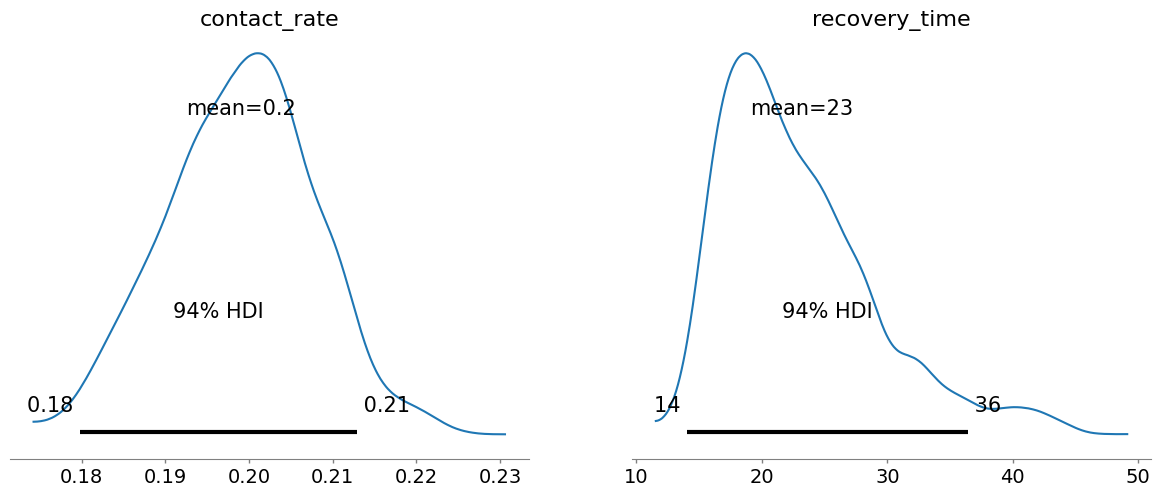

In [29]:
az.plot_posterior(idata)